# ARGUS-FEDER — How does helium affect deuterium retention in tungsten?

This notebook shows **ARGUS**, a notebook-native AI agent, working on one
question and three follow-ups. The questions are typed in plain English into an
`%%ask` cell. The agent decides what to look up, writes and runs its own code,
and reports back.

**Who wrote what.** This introduction and the short note above each question are
written by us, at SDSC. Everything inside and below an `%%ask` cell is the
agent's own: the steps it took, the code it wrote, the figures and the answer.
The questions themselves were written with Greg Sinclair and Yiming Chen, whose
group produced the data.

## The question

A burning plasma produces helium and neutrons due to the fusion of hydrogen
isotopes. The first wall surfaces in a fusion device are bombarded by these
species with varying intensities. The degree to which implanted helium affects
the accumulation of implanted hydrogenic particles (deuterium and tritium) in
the plasma-facing walls is a first-order question for a reactor, as it impacts
the safety and fuel economy of the overall plant.

The delivery this notebook works from was built to ask exactly that. Tungsten
coupons were pre-exposed to helium plasma in the PISCES-A linear device at two
temperatures. Then, both these exposed samples and pristine samples were
subsequently exposed to deuterium plasma in the DIII-D tokamak via the DiMES
sample exposure probe. The retention of hydrogenic and helium species was
measured afterwards by three laboratory techniques.

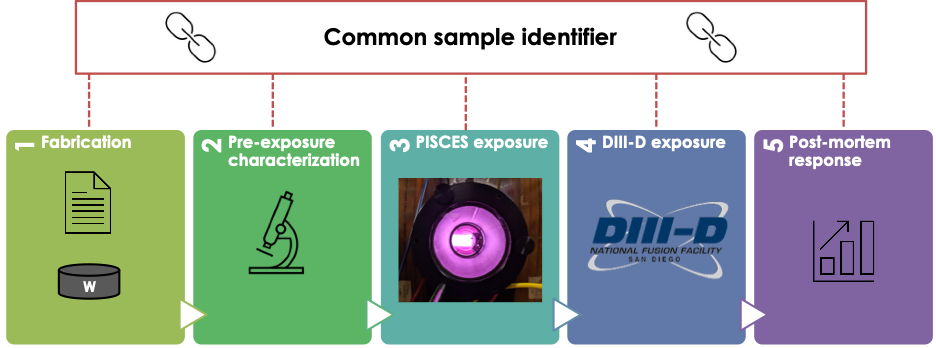

*Each coupon carries one identifier through every stage, which is what makes a
question about the end of its life answerable from the beginning of it.*

The question is asked plainly first. The follow-ups then press on the two places
where a single number could mislead: which technique produced it, and which
plasma the coupon saw. The last question asks what the data cannot support.


In [ ]:
%reset

## 1 — The question, as asked

Put plainly, the way it would be asked in a meeting, with no constraint on how
it should be answered.


I’ll query the materials dataset, identify helium–deuterium retention comparisons in tungsten, and use attached literature only if interpretation needs supporting context.

I’m reading the materials skill to use the documented lakehouse functions and preserve the dataset’s intended meaning.

The skill requires checking its accumulated error fixes, so I’m reading the existing d3d-materials learnings before writing any query code.

The materials workflow mandates an attached-paper search, so I’m reading the literature skill before constructing the combined dataset query.

The workflows and known pitfalls are now clear; I’ll begin by discovering samples, measurements, experiment cells, provider notes, and relevant paper passages.

...

I’m listing the working folder to audit that every promised table, chart, query record, and script was saved in the allowed location.

I’m reading the scalar comparison CSV to verify the exact values and signs that will be quoted in the report.

I’m reading the LAMS summary CSV to verify the depth-profile results and their propagated uncertainty before interpreting them.

The audit confirms all quoted numbers have CSV/JSON support, no image was opened, and no edit-and-retry cycle required a learnings update.

**Short answer** : Helium can reduce deuterium retention in tungsten by creating a helium-affected near-surface layer that impedes deuterium penetration and promotes recycling back to the surface. In these measurements, however, the effect is strongly conditional: the 800 K helium-preloaded coupon retained **42–77% less deuterium under H-mode exposure** , while other helium-preload and plasma-regime combinations increased some surface or areal measurements by **14–121%** .

## What the experiment shows

Tungsten coupons were either left without helium or pre-exposed to helium in PISCES-A, then exposed to deuterium plasmas in DIII-D. Helium was implanted at 70 eV under two treatment levels:

- **600 K helium exposure** : $1.0\times10^{25}$ He m$^{-2}$.
- **800 K helium exposure** : $1.2\times10^{25}$ He m$^{-2}$.

The resulting deuterium concentrations were measured independently by ERDA, NRA, and LAMS. These techniques have different probing depths and units and therefore should not be averaged or ranked.

The table reports the change relative to the no-helium coupon exposed in the same DIII-D regime:

| DIII-D regime | Helium preload | ERDA areal D | NRA surface, 0–0.5 µm | NRA sub-surface, 0.5–3 µm | LAMS profile area, 0.024–2.155 µm |
|---|---:|---:|---:|---:|---:|
| H-mode | 800 K | −42% ± 5 percentage points | −68% | −77% | −50% ± 25 percentage points |
| H-mode | 600 K | +27% ± 9 percentage points | +14% | +33% | +68% ± 89 percentage points |
| L-mode | 800 K | +36% ± 9 percentage points | +35% | −59% | −33% ± 45 percentage points |
| L-mode | 600 K | +63% ± 10 percentage points | +121% | −24% | −4% ± 61 percentage points |

**Uncertainty note** : ERDA uncertainties were propagated from the reported standard deviations. NRA supplied no uncertainty values. The LAMS profile-area uncertainties were propagated from pointwise standard deviations assuming independence and are large, so those profile summaries are correspondingly weak constraints.


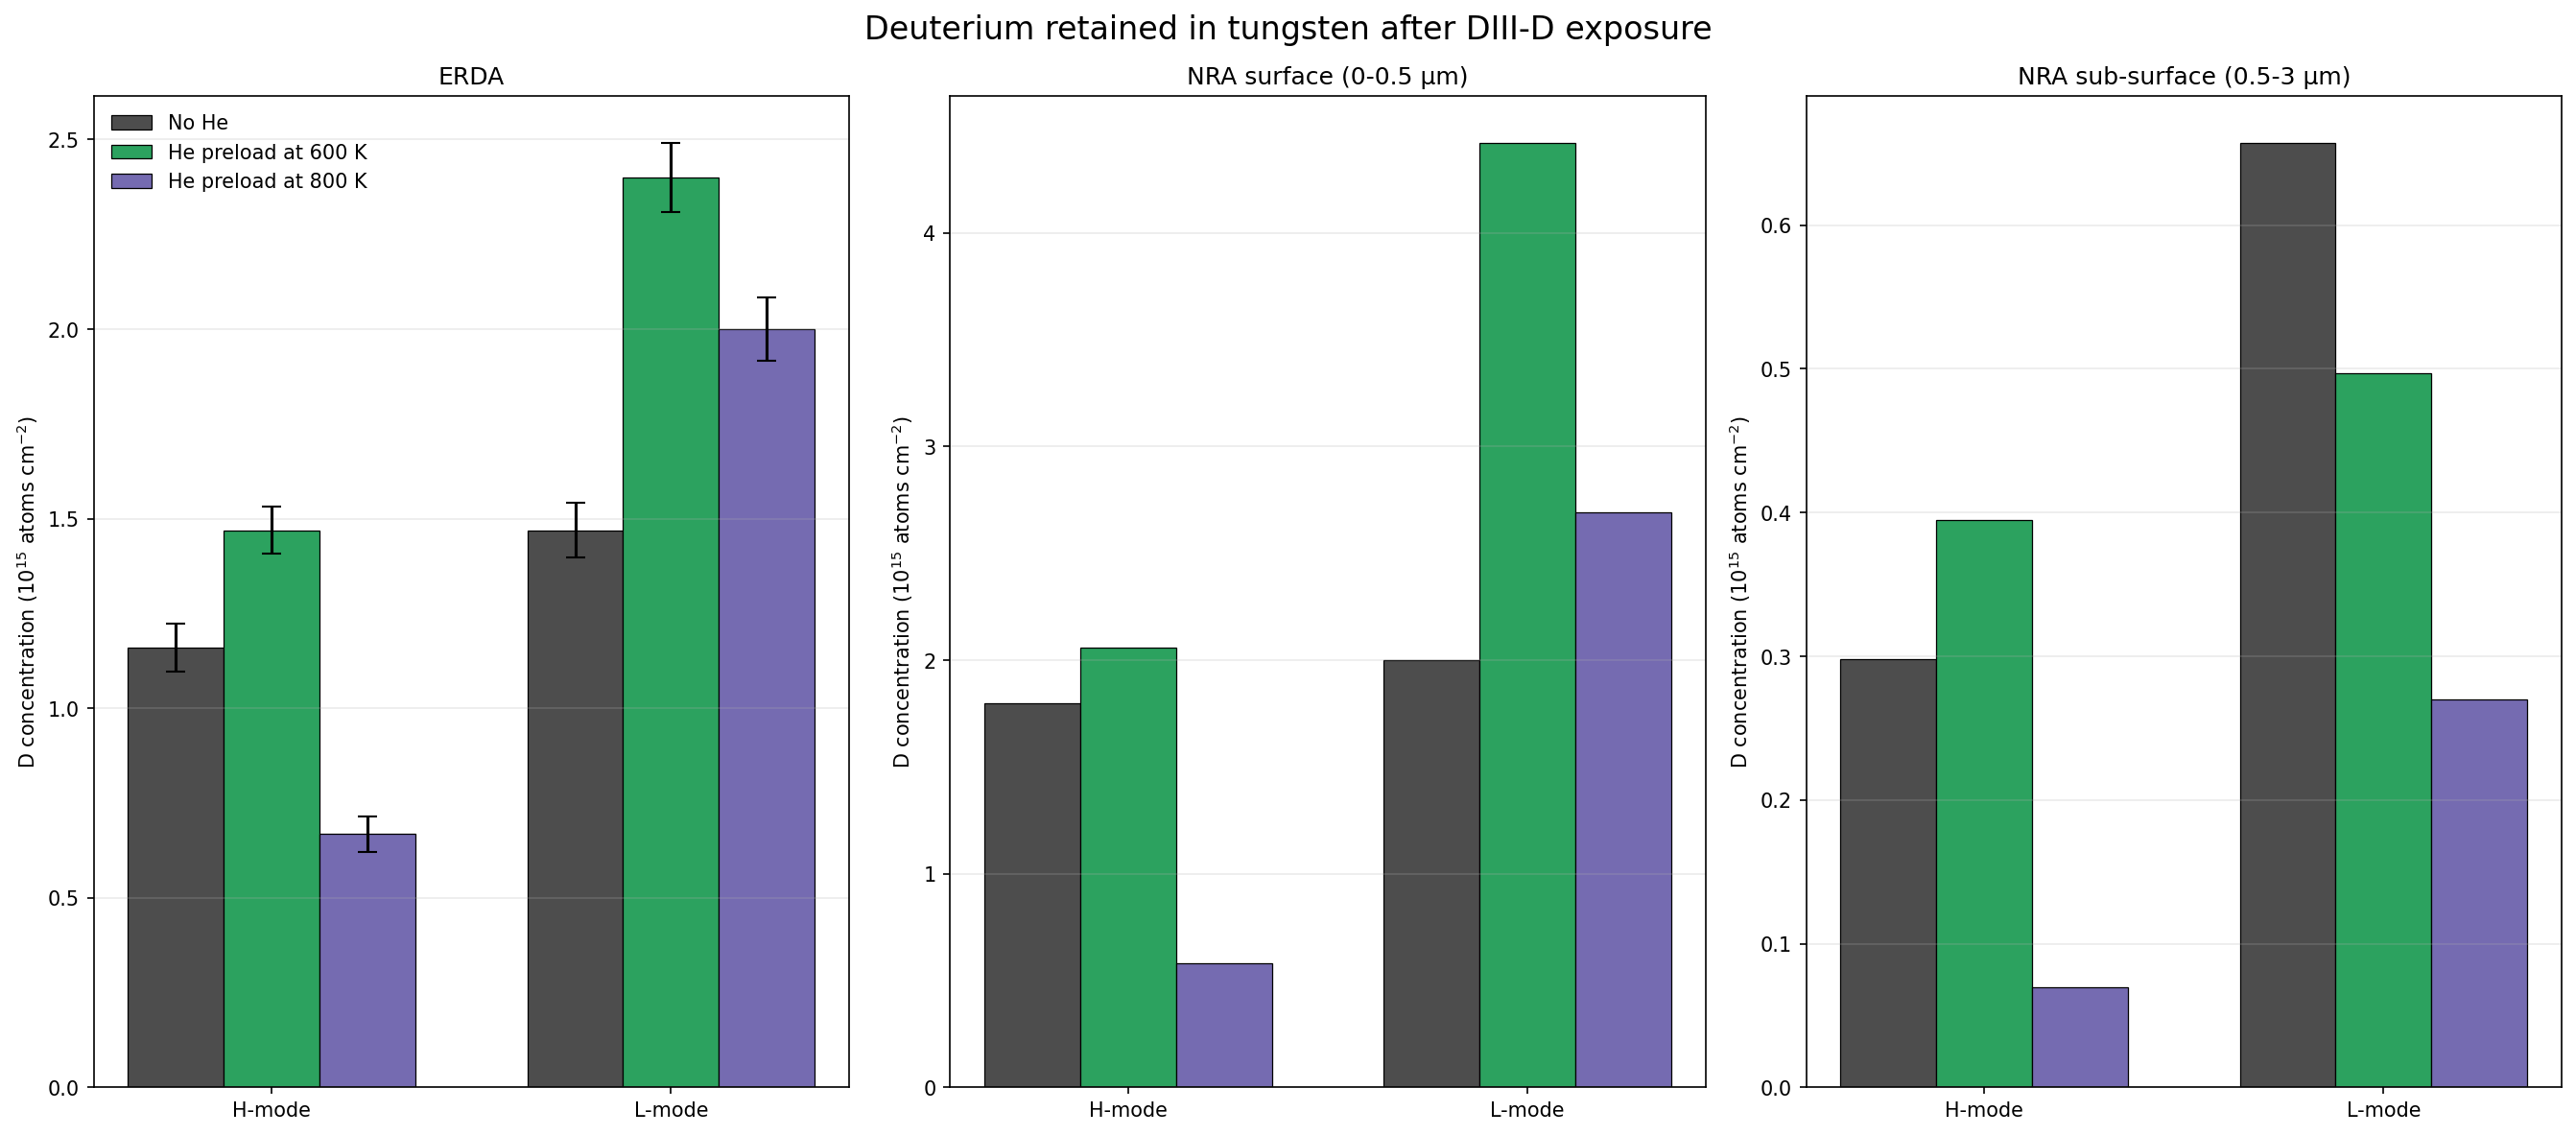

### Clearest reduction: 800 K helium preload in H-mode

All three methods agree on the direction of the effect for this condition:

- **ERDA** decreased from $1.16\times10^{15}$ to $6.68\times10^{14}$ D atoms cm$^{-2}$, a **42% reduction** .
- **NRA surface band** decreased from $1.80\times10^{15}$ to $5.82\times10^{14}$ D atoms cm$^{-2}$, a **68% reduction** .
- **NRA sub-surface band** decreased from $2.98\times10^{14}$ to $6.96\times10^{13}$ D atoms cm$^{-2}$, a **77% reduction** .
- **LAMS profile area** was approximately half that of the no-helium H-mode coupon, although its reported variability is substantial.

This is the strongest evidence in this delivery for helium suppressing deuterium uptake throughout both the near-surface and sub-surface regions.

### Other conditions reveal depth dependence

The effect was not uniformly suppressive:

- With the **600 K helium preload in H-mode** , ERDA, both NRA bands, and the central LAMS profile-area estimate all increased.
- In **L-mode** , helium increased ERDA and NRA surface values but reduced NRA sub-surface deuterium. This indicates a possible redistribution toward the surface rather than a simple increase or decrease in the entire retained inventory.
- The LAMS central estimates were lower for both 800 K coupons, but their uncertainty ranges are broad.


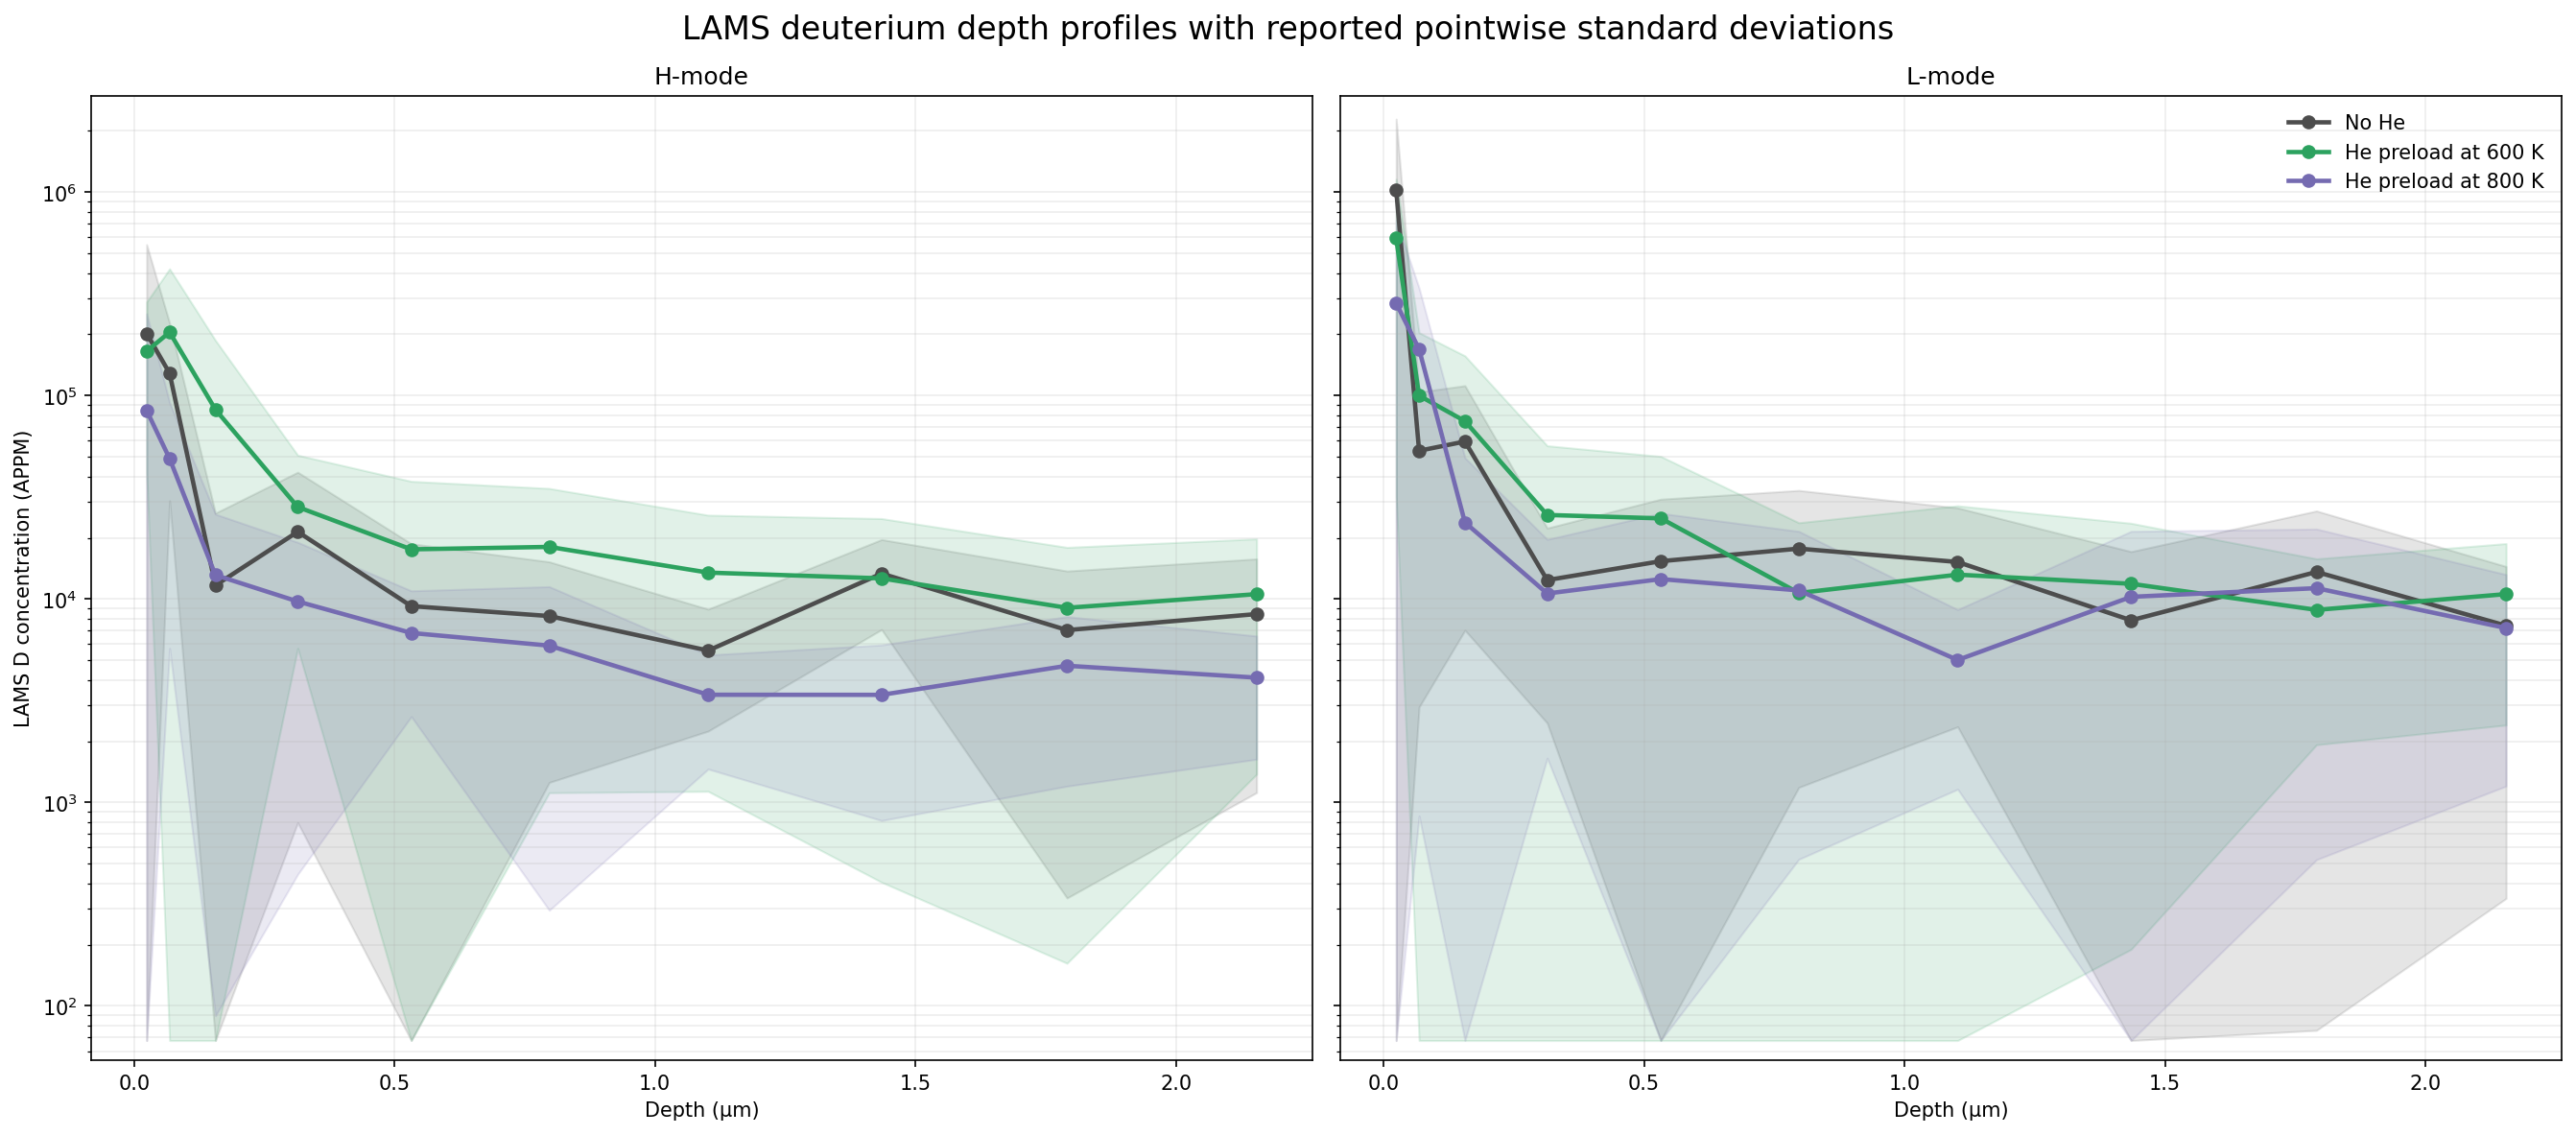

## Why helium can reduce retention

Baldwin and Doerner’s attached study reports that implanted helium has very low solubility in tungsten and precipitates into a nanobubble-rich near-surface layer. Their experiments and transport modeling indicate that this layer can:

1. **Alter deuterium migration through the near-surface tungsten** , acting as a permeation barrier.
2. **Reduce the fraction of incident deuterium that penetrates the surface** .
3. **Increase deuterium recycling back to the plasma** , leaving less deuterium available for deeper trapping.

Their modeling found that nanobubble porosity alone was insufficient; altered deuterium migration properties and reduced penetrating flux were also needed. The helium fluences in the present delivery—&#36;1.0&#36; to $1.2\times10^{25}$ m$^{-2}$—are in the range where the paper reports the reduced-inventory effect.

The present measurements therefore support that mechanism most clearly for the **800 K helium-preloaded H-mode coupon** . The increases or depth-dependent changes under other conditions show that helium is not a universal retention suppressor: the final outcome depends on the helium exposure history, subsequent plasma regime, and the depth sampled by the diagnostic.

## Important limitations

- **One coupon per experimental cell** : all nine design cells contain only one sample. Treatment differences therefore cannot be separated from coupon-to-coupon variability.
- **The helium treatments differed in more than temperature** : the 600 K and 800 K exposures also had different fluxes, durations, and slightly different fluences. The contrast cannot be attributed to temperature alone.
- **DIII-D sample temperature was not measured** : neither bulk nor surface temperature during the deuterium exposure is available.
- **Methods are not interchangeable** : ERDA, NRA, and LAMS probe different regions and report different physical representations. Their disagreement—especially between surface and sub-surface NRA results—is part of the finding rather than something to average away.
- **This was sequential exposure** : the samples were preloaded with helium and subsequently exposed to deuterium. Simultaneous mixed He–D irradiation could behave differently.

## Data files

- `helium_deuterium_retention_measurements.csv` — method-specific ERDA, NRA, and LAMS measurements for the six DIII-D-exposed coupons.
- `helium_deuterium_scalar_comparisons.csv` — ERDA and NRA values, ratios, percentage changes, and propagated ERDA uncertainties relative to no-helium controls.
- `helium_deuterium_lams_profile_summary.csv` — trapezoidal LAMS profile summaries and uncertainty propagation.
- `helium_deuterium_experiment_design.csv` — samples, treatments, exposure combinations, and replication counts.
- `helium_deuterium_exposure_conditions.csv` — recorded helium and DIII-D exposure parameters in tabular form.
- `helium_deuterium_exposure_conditions.json` — complete exposure-condition response.
- `helium_deuterium_discovery.json` — samples, quantities, experiment design, observations, provider notes, and scoped literature results.
- `helium_deuterium_document_hits.json` — text-document search results for helium and retention terminology.
- `nra_analyst_commentary.txt` — extracted NRA analyst-commentary lines from the delivered workbook.

All files are in:

`/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_`

## References

M.J. Baldwin and R.P. Doerner (2017) Hydrogen isotope transport across tungsten surfaces exposed to a fusion relevant He ion fluence. Nuclear Fusion 57 076031 doi:10.1088/1741-4326/aa70b1

In [4]:
%%ask
How does the presence of helium affect the retention of deuterium in tungsten?

## 2 — Does the answer depend on the measurement technique?

Three techniques measured retention on these coupons, and they do not all report
the same quantity or carry the same uncertainty.


I’ll compare each technique’s sampling depth and uncertainty treatment, then quantify where their conclusions agree or diverge.

I’m reading the materials skill to use its authoritative measurement and file-access workflow.

I’m checking prior d3d-materials learnings so known query and plotting pitfalls are avoided.

I’m reading the literature skill because the materials workflow requires attached-paper context for measurement limitations.

The required workflows are clear: enumerate all methods, query profiles separately, inspect provider notes, design replication, and search attached papers.

...

The calculations show strong method dependence: only H-mode/800 K agrees in direction across all methods; L-mode NRA even reverses sign with depth.

I’m checking the saved uncertainty summary to ensure every reported range is traceable to a text data file.

The outputs are complete: ERDA uncertainties are modest, NRA has none supplied, and LAMS pointwise scatter is large enough to blur most profile-area contrasts.

I’m performing the required closing audit: both scripts succeeded on their first run, with no edit-and-retry cycle or unrecorded learning.

**Short answer** : The conclusion depends strongly on what depth and representation the measurement technique samples. In H-mode, the central estimates are directionally consistent—800 K helium preloading lowers deuterium by every method, whereas 600 K preloading raises it—but in L-mode, the apparent helium effect reverses with depth: ERDA and surface NRA increase while sub-surface NRA and the central LAMS estimates decrease. The uncertainty evidence is also uneven: ERDA has relatively small supplied standard deviations, NRA has no supplied uncertainties, and LAMS has large pointwise scatter.

## Technique-by-technique comparison

All changes below are relative to the **no-helium coupon exposed in the same DIII-D regime** . A positive value means that the helium-preloaded coupon had more measured deuterium; a negative value means less.

| DIII-D regime | Helium preload | ERDA areal measurement | NRA surface, 0–0.5 µm | NRA sub-surface, 0.5–3 µm | LAMS profile area, 0.024–2.155 µm |
|---|---:|---:|---:|---:|---:|
| H-mode | 800 K | −42% ± 5 percentage points | −68%; uncertainty not supplied | −77%; uncertainty not supplied | −50% ± 25 percentage points |
| H-mode | 600 K | +27% ± 9 percentage points | +14%; uncertainty not supplied | +33%; uncertainty not supplied | +68% ± 89 percentage points |
| L-mode | 800 K | +36% ± 9 percentage points | +35%; uncertainty not supplied | −59%; uncertainty not supplied | −33% ± 45 percentage points |
| L-mode | 600 K | +63% ± 10 percentage points | +121%; uncertainty not supplied | −24%; uncertainty not supplied | −4% ± 61 percentage points |

The quoted ERDA and LAMS uncertainties are one propagated standard deviation under the assumptions described below. They are not confidence intervals for a replicated treatment effect.


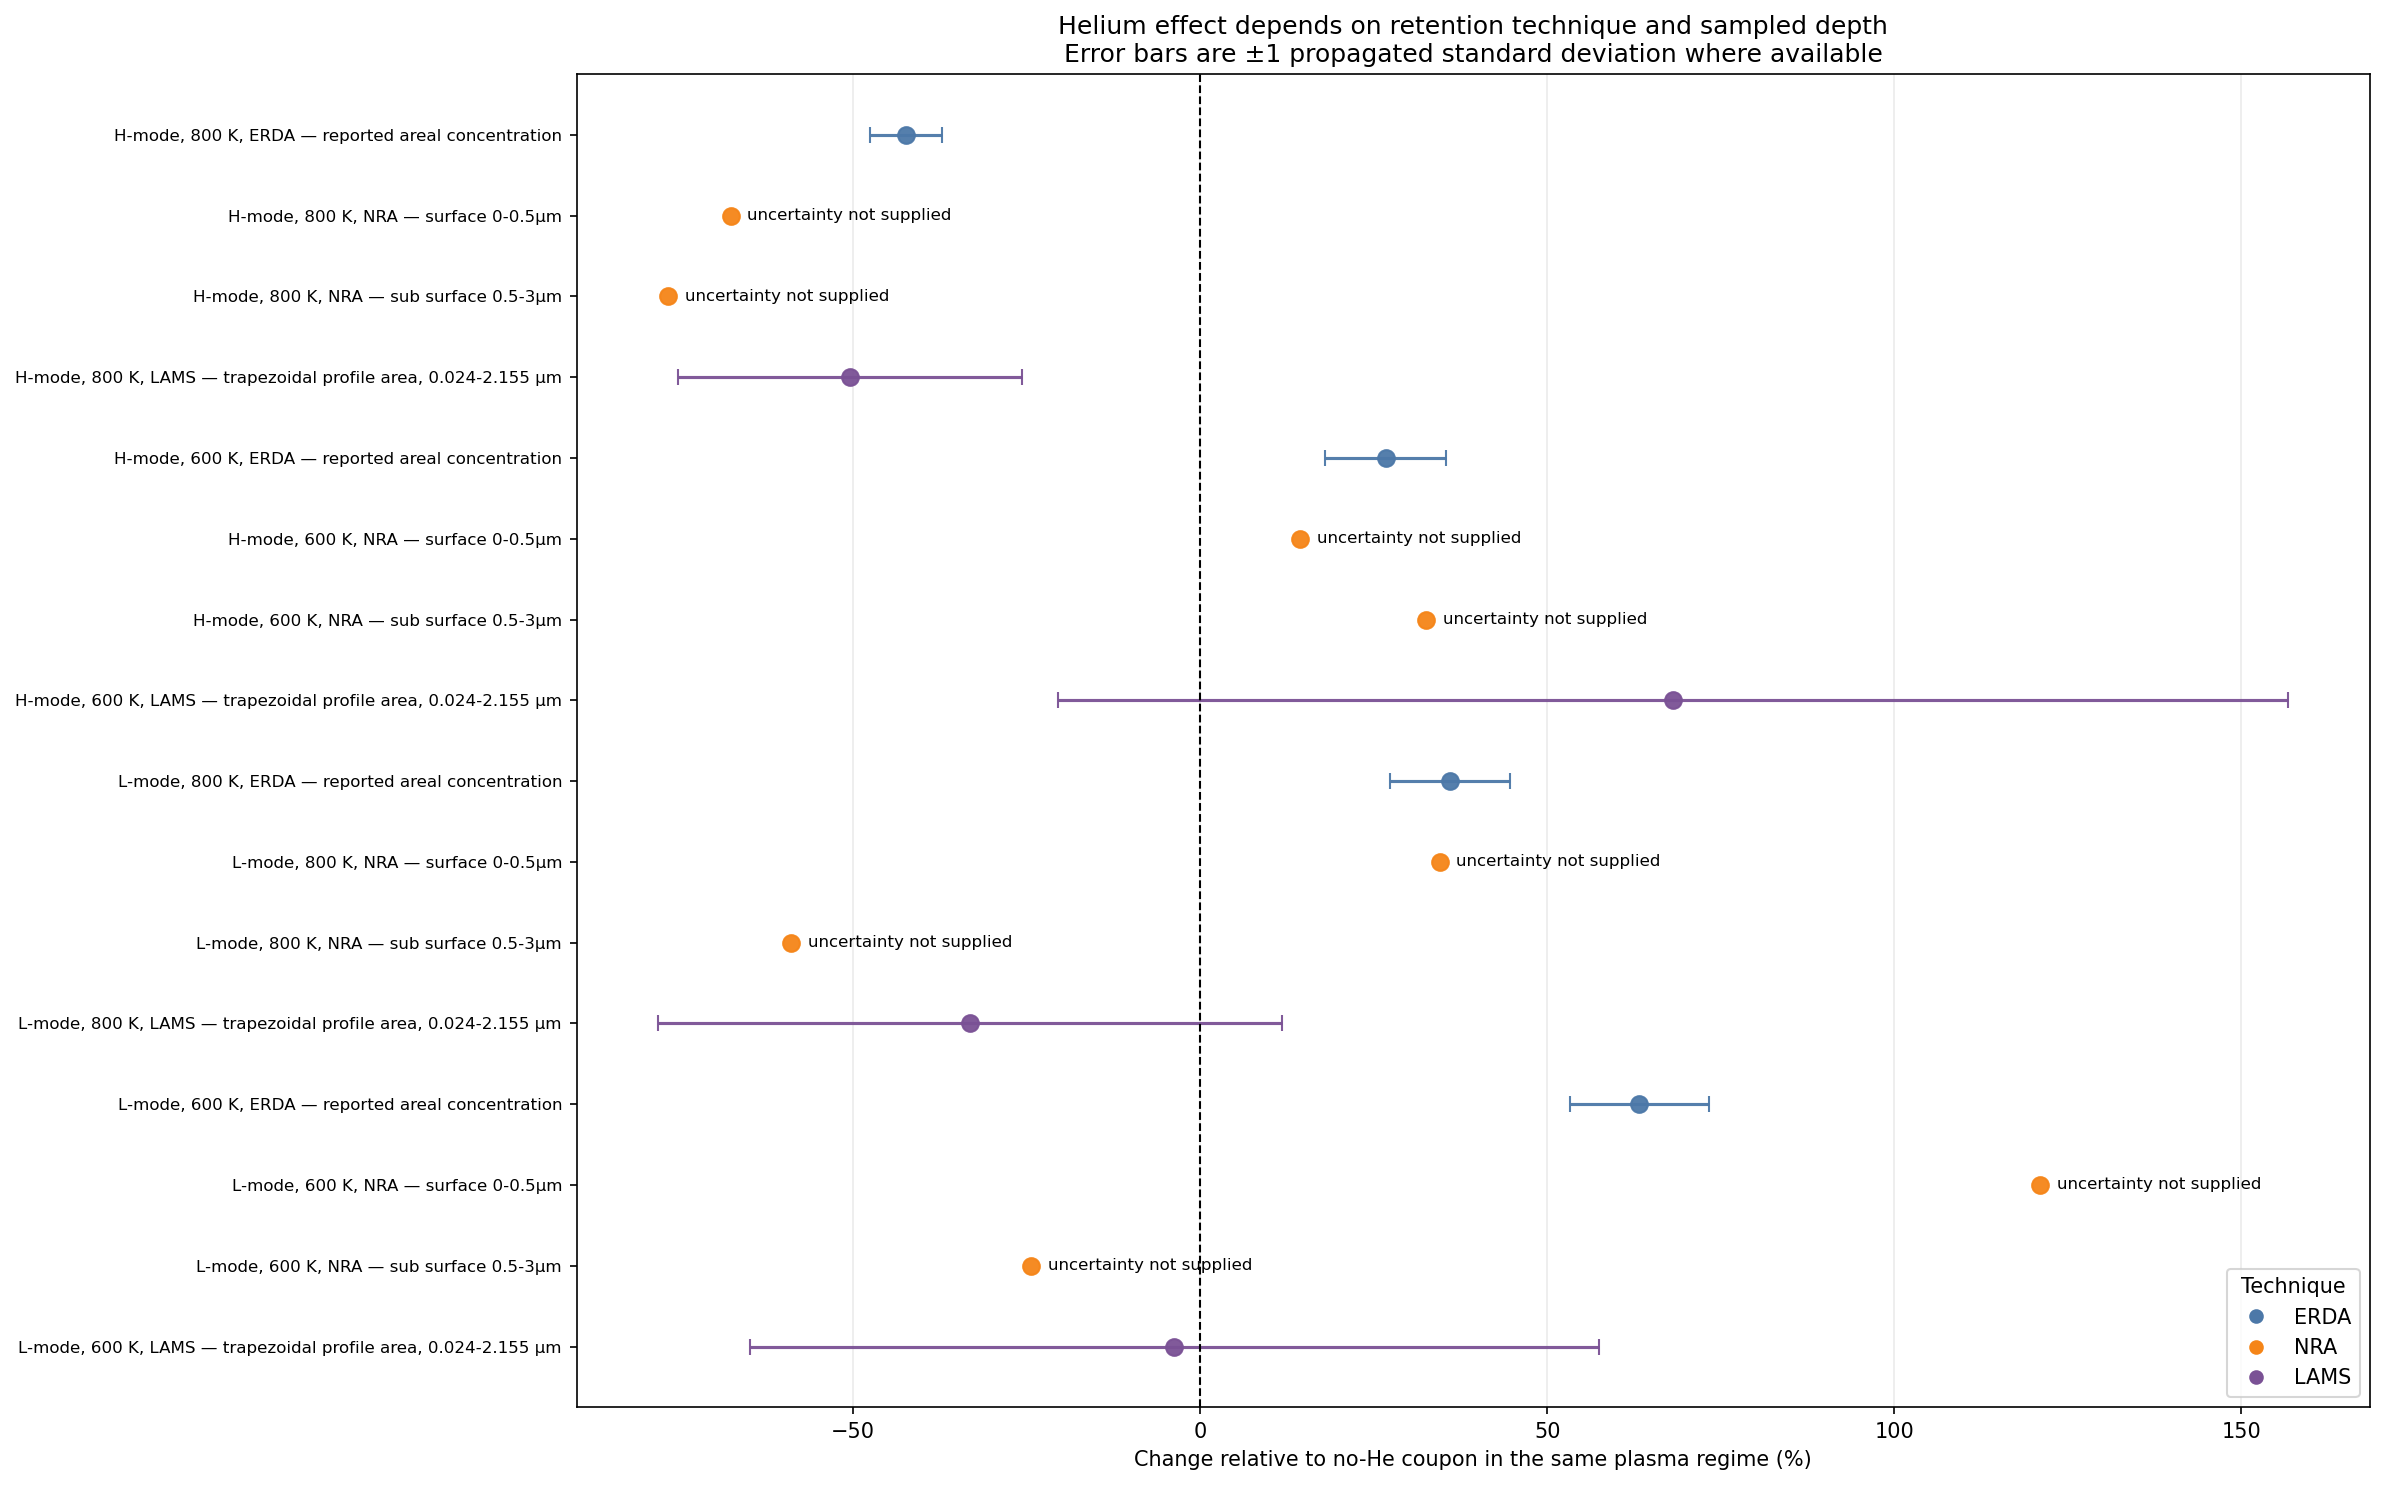

### ERDA: one scalar areal measurement per coupon

ERDA reports deuterium in atoms cm$^{-2}$ as one scalar value for each coupon. The delivered scalar does not separate surface from sub-surface deuterium.

Its conclusion is therefore simple but not universal:

- **H-mode, 800 K preload** : deuterium decreases by **42% ± 5 percentage points** .
- **H-mode, 600 K preload** : deuterium increases by **27% ± 9 percentage points** .
- **L-mode, 800 K preload** : deuterium increases by **36% ± 9 percentage points** .
- **L-mode, 600 K preload** : deuterium increases by **63% ± 10 percentage points** .

Thus, from ERDA alone, helium suppresses retention only for the **800 K/H-mode condition** . The other three comparisons show higher areal deuterium after helium preloading.

### NRA: the answer changes with depth

NRA reports separate areal quantities for two depth bands:

- **Surface** : 0–0.5 µm.
- **Sub-surface** : 0.5–3 µm.

For the H-mode coupons, the two NRA bands agree in direction:

- The 800 K preload reduces both surface and sub-surface deuterium.
- The 600 K preload increases both.

For the L-mode coupons, however, NRA gives opposite conclusions at different depths:

- **800 K/L-mode** : surface deuterium increases **35%** , while sub-surface deuterium decreases **59%** .
- **600 K/L-mode** : surface deuterium increases **121%** , while sub-surface deuterium decreases **24%** .

This is evidence for **redistribution with depth** , not merely a uniform increase or decrease in the retained inventory. ERDA’s increases in L-mode resemble the NRA surface result, while the deeper NRA band points in the opposite direction.

The NRA analyst also recorded that the measured sub-surface deuterium was above an approximately **10 APPM detection limit** . That statement supports detection of sub-surface deuterium, but it does not provide an uncertainty for the reported atoms cm$^{-2}$ values.

### LAMS: a resolved profile, but with large scatter

LAMS provides ten deuterium-concentration points per coupon from **0.024 to 2.155 µm** , reported in APPM. I integrated each profile by the trapezoidal rule to obtain a within-method profile-area summary in APPM µm.

This derived area must not be treated as the same physical quantity as the ERDA or NRA values in atoms cm$^{-2}$. It is useful for comparing one LAMS profile with another, but converting it into a physical areal inventory would require additional calibration or density information.

The central LAMS estimates are:

- **H-mode, 800 K** : −50%.
- **H-mode, 600 K** : +68%.
- **L-mode, 800 K** : −33%.
- **L-mode, 600 K** : −4%.

The LAMS uncertainties are large. Using the supplied pointwise sigma values and assuming independent profile points, the treated-minus-control differences are only approximately:

- **1.27 standard deviations** for H-mode/800 K.
- **0.92 standard deviations** for H-mode/600 K.
- **0.56 standard deviations** for L-mode/800 K.
- **0.06 standard deviations** for L-mode/600 K.

Therefore, LAMS supports the **direction** of the H-mode/800 K reduction as a central estimate, but does not establish any of the four profile-area differences strongly on its own.

## How uncertain are the measurements?

### ERDA uncertainty

Every ERDA result for a DIII-D-exposed coupon has a supplied standard deviation.

- **Relative standard-deviation range** : 3.8–7.2%.
- **Median relative standard deviation** : 4.5%.
- **Propagated uncertainty on helium-induced percentage changes** : approximately 5–10 percentage points.

If only these supplied analytical standard deviations are considered, the ERDA treated-versus-control differences range from approximately **3.5 to 8.1 propagated standard deviations** away from zero.

That does **not** make them replicated treatment effects. Each condition contains only one coupon, so these calculations omit coupon-to-coupon variability, treatment reproducibility, and any systematic calibration error not included in the supplied standard deviations.

### NRA uncertainty

No NRA standard deviations or other quantitative error bars were supplied for any of the twelve DIII-D-exposed sample-band values.

Consequently:

- The percentage changes can be calculated.
- Their uncertainty cannot be propagated from this delivery.
- Their statistical significance cannot be assessed.
- A missing uncertainty must not be interpreted as zero uncertainty or exceptional precision.

The analyst’s detection-limit statement establishes that the sub-surface signal was considered detected, but it does not quantify uncertainty in the magnitude of the treatment contrasts.

### LAMS uncertainty

All 60 LAMS profile points for the six DIII-D-exposed coupons have supplied pointwise sigma values, but those values are large relative to their measured concentrations:

- **Relative pointwise sigma range** : 47–199%.
- **Median relative pointwise sigma** : 95%.

I propagated these pointwise values into the profile integrals as

$$
\sigma_A =
\sqrt{\sum_i \left(w_i \sigma_i\right)^2},
$$

where $w_i$ are trapezoidal integration weights. This calculation assumes that errors at different profile depths are independent.

That assumption is not verified. If errors are correlated across depth, the derived profile-area uncertainties could be underestimated or otherwise mischaracterized. In addition, the delivered workbook labels its depth-error column as **incorrect** , so depth-coordinate uncertainty was excluded entirely. The profile-area uncertainties therefore describe only a limited, explicitly derived component of total uncertainty.

## Overall interpretation

The most defensible technique-dependent interpretation is:

1. **H-mode, 800 K helium preload** : every method and depth band has a lower central deuterium measurement. This is the clearest evidence for helium-associated suppression, although NRA lacks error bars and LAMS is noisy.

2. **H-mode, 600 K helium preload** : every central estimate is higher, but the LAMS increase is poorly constrained. This condition does not support a universal helium-induced reduction.

3. **L-mode helium preloads** : helium appears to move the retained-deuterium distribution toward the near surface. ERDA and surface NRA increase, while the 0.5–3 µm NRA band decreases. LAMS central estimates are lower or nearly unchanged but have broad uncertainty.

4. **No cross-method average is justified** : ERDA, NRA, and LAMS differ in depth sensitivity, spatial representation, units, and uncertainty structure. Their disagreement is physically informative rather than something to remove by averaging or ranking the methods.

5. **Experimental uncertainty exceeds the reported instrument error budget** : all nine experimental-design cells contain only one coupon. None of the supplied or derived error bars captures between-coupon variability, so the experiment does not provide a population-level uncertainty on the helium treatment effect.

Finally, “600 K” and “800 K” identify two different helium-preload conditions, but those treatments also differed in flux, duration, and slightly in fluence. Their contrast should not be attributed to temperature alone.

## Data files

All files are in `/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_`.

- `helium_effect_by_retention_technique.csv` — treated/control values, ratios, percentage changes, propagated uncertainties, and depth representations for all techniques.
- `retention_measurements_by_technique.csv` — underlying ERDA, NRA, and LAMS measurements with supplied uncertainties.
- `retention_technique_uncertainty_summary.csv` — uncertainty coverage and relative-standard-deviation ranges by technique.
- `lams_profile_uncertainty_summary.csv` — integrated LAMS profiles, propagated profile-area sigma values, depth ranges, and pointwise relative scatter.
- `retention_technique_query.json` — authoritative lakehouse results, experimental design, provider guidance, document-search results, and attached-literature retrieval used in the analysis.

In [5]:
%%ask
How does the answer depend on the retention measurement technique? Can you 
comment on the uncertainty in these measurements?

## 3 — Retention against the DIII-D plasma condition

The coupons were exposed in two confinement regimes. This asks for the effect of
that difference, in total and with depth, with the method dependence from the
previous question carried through.


I’ll compare L-mode against H-mode within each helium-preload condition, separating total/areal measurements from depth-resolved profiles and propagating available uncertainties.

I’m reading the materials-data workflow before writing code so the query follows the dataset’s required access pattern.

The skill requires checking its recorded error patterns next; I’m reading those before constructing the data query.

The materials workflow mandates an attached-literature search, so I’m checking the literature retrieval rules before querying.

The query rules are clear: discover quantities and methods, inspect design/provider notes, batch all samples, and retrieve scalar and profile measurements separately.

...

I’m validating the saved method-summary and NRA depth-band tables directly from their text CSVs; no image files will be opened.

The scalar tables are consistent; I’m now validating all 30 paired LAMS depth rows and their propagated uncertainties from the text CSV.

The LAMS table confirms mixed-sign depth changes for no-He and 600 K, but positive changes at all ten depths for 800 K; I’m validating campaign-condition values next.

Validation is complete: all reported numbers trace to saved CSVs, and there was no edit-and-retry cycle requiring a new skill-learning entry.

**Short answer** : Relative to H-mode, the L-mode campaign produced more measured deuterium in every helium-preload class according to both ERDA and the summed NRA depth bands. The increase ranged from about **27% to 199% by ERDA** and **27% to 354% by NRA** , with the largest change for tungsten preloaded with helium at 800 K. LAMS was less uniform: its integrated profile increased **75%** without helium, was essentially unchanged after the 600 K preload, and increased **136%** after the 800 K preload, but these LAMS differences have large propagated uncertainties.

## Comparison definition

Each L-mode coupon is compared with the H-mode coupon having the same helium-preload history:

- **No helium** : W-DL versus W-DH.
- **600 K helium preload** : W-He600-DL versus W-He600-DH.
- **800 K helium preload** : W-He800-DL versus W-He800-DH.

The reported percentage change is

$$
\Delta_{\mathrm{L/H}} = 100\left(\frac{D_{\mathrm{L}}}{D_{\mathrm{H}}}-1\right).
$$

A positive value means greater measured D retention following the L-mode campaign.

## The plasma campaigns differed in more than confinement mode

The experimental labels are L-mode and H-mode, but several recorded exposure parameters changed simultaneously:

| Recorded condition | H-mode campaign | L-mode campaign | L relative to H |
|---|---:|---:|---:|
| Average heat flux | 0.72 MW m$^{-2}$ | 0.47 MW m$^{-2}$ | −34.7% |
| Average particle fluence | $6.7\times10^{22}$ m$^{-2}$ | $7.8\times10^{22}$ m$^{-2}$ | +16.4% |
| Average particle flux | $4.5\times10^{21}$ m$^{-2}$ s$^{-1}$ | $7.5\times10^{21}$ m$^{-2}$ s$^{-1}$ | +66.7% |
| Exposure duration | 12.5 s | 10.0 s | −20.0% |
| Impact energy | 150 eV | 175 eV | +16.7% |
| Electron density, $n_e$ | $5.76\times10^{18}$ m$^{-3}$ | $7.35\times10^{18}$ m$^{-3}$ | +27.6% |
| Electron temperature, $T_e$ | 27.9 eV | 40.8 eV | +46.2% |

Consequently, the measured differences are best described as **L-campaign versus H-campaign differences** . They cannot be assigned uniquely to confinement mode: the L-mode samples also received greater particle fluence, particle flux, impact energy, density, and electron temperature, but lower heat flux and a shorter exposure.

## Total or method-level retention summaries

The three techniques do not produce interchangeable totals:

- **ERDA** supplies one method-reported areal D concentration for each coupon.
- **NRA** supplies separate areal inventories for 0–0.5 and 0.5–3 µm. Their sum is the reported 0–3 µm inventory.
- **LAMS** supplies an APPM concentration profile. Its trapezoidal integral is a useful within-LAMS profile summary in APPM µm, but it is **not** a calibrated areal inventory equivalent to ERDA or NRA.

| Helium preload | ERDA, H → L | ERDA change | NRA 0–3 µm, H → L | NRA change | LAMS profile area, H → L | LAMS change |
|---|---:|---:|---:|---:|---:|---:|
| None | $1.16\to1.47\times10^{15}$ atoms cm$^{-2}$ | +26.7% ± 9.2 percentage points | $2.098\to2.657\times10^{15}$ atoms cm$^{-2}$ | +26.6%; no uncertainty supplied | $3.342\to5.836\times10^4$ APPM µm | +74.7% ± 109.5 percentage points |
| 600 K | $1.47\to2.40\times10^{15}$ atoms cm$^{-2}$ | +63.3% ± 9.2 percentage points | $2.455\to4.917\times10^{15}$ atoms cm$^{-2}$ | +100.3%; no uncertainty supplied | $5.6190\to5.6193\times10^4$ APPM µm | +0.006% ± 53.7 percentage points |
| 800 K | $0.668\to2.00\times10^{15}$ atoms cm$^{-2}$ | +199.4% ± 24.8 percentage points | $0.6516\to2.960\times10^{15}$ atoms cm$^{-2}$ | +354.3%; no uncertainty supplied | $1.654\to3.902\times10^4$ APPM µm | +135.9% ± 131.5 percentage points |


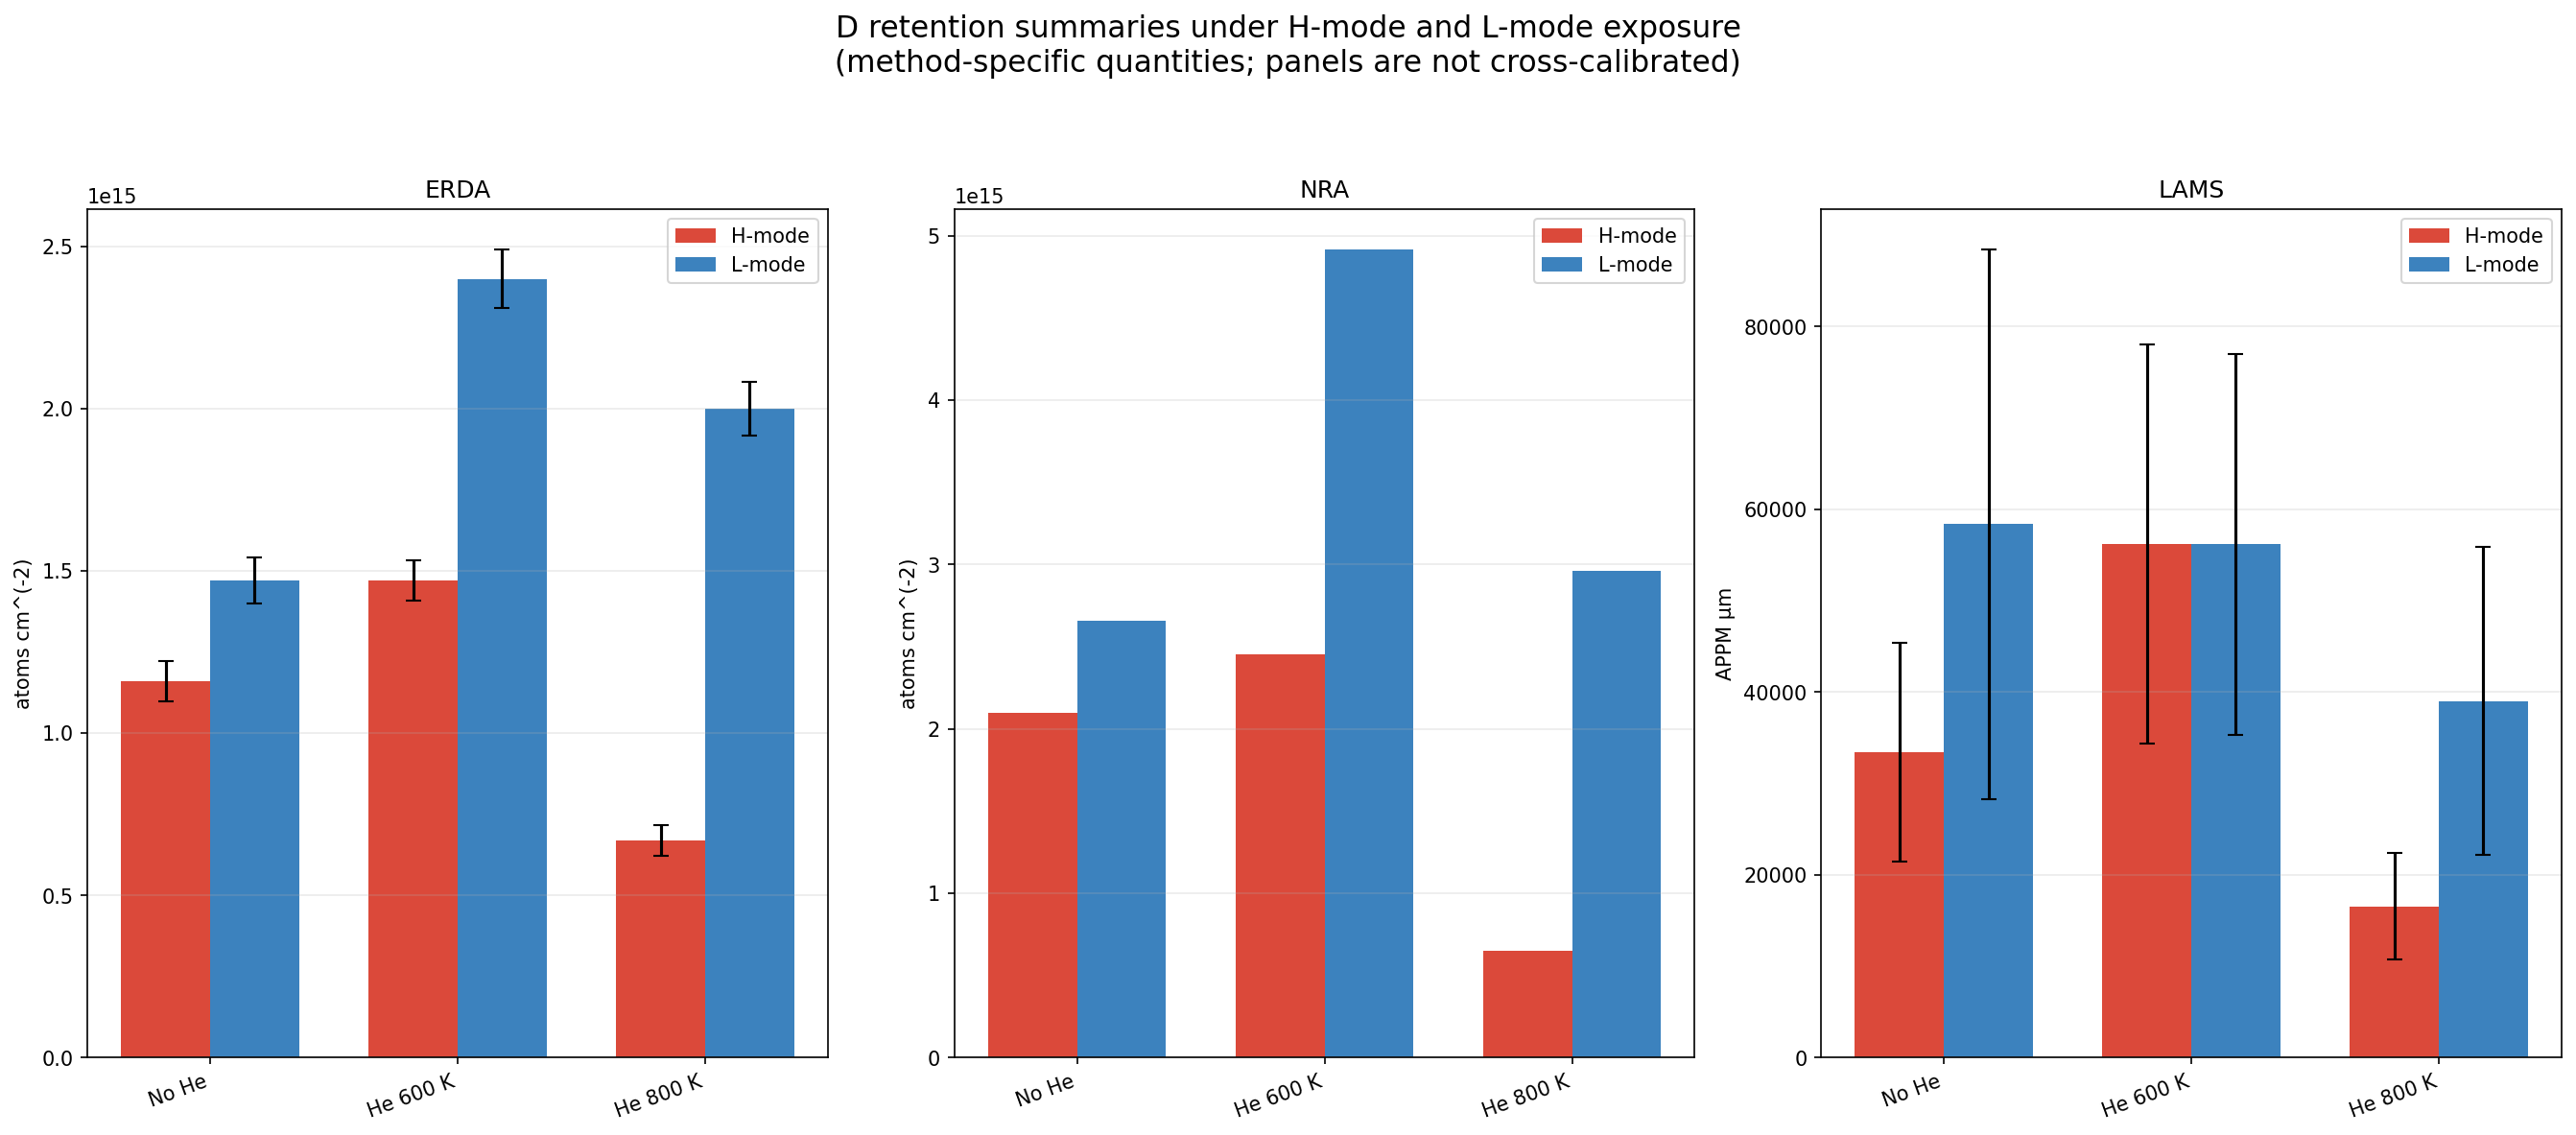

### Technique-dependent interpretation of the totals

**No helium preload** :

- ERDA and summed NRA agree closely on the relative change: **+26.7%** and **+26.6%** , respectively.
- The LAMS profile-area central estimate increases more, by **74.7%** , but the uncertainty on that increase is larger than the increase itself.
- Thus, ERDA and NRA support a moderate L-over-H difference, while LAMS does not constrain its size well.

**600 K helium preload** :

- ERDA increases by **63.3%** .
- NRA’s summed 0–3 µm inventory approximately doubles: **+100.3%** .
- The integrated LAMS profile is essentially unchanged: **+0.006%** .
- This is the strongest disagreement among the techniques. It indicates that the answer is sensitive to probing depth, spatial representation, calibration, and LAMS variability—not simply a single coupon-wide multiplicative change.

**800 K helium preload** :

- Every method gives a higher central estimate following L-mode.
- ERDA increases by a factor of **2.99** , NRA by **4.54** , and the LAMS profile-area index by **2.36** .
- This is the strongest qualitative agreement among the methods, although the numerical factors differ substantially and the LAMS uncertainty remains large.

## Depth dependence measured by NRA

NRA divides the retained D inventory into two non-overlapping depth bands.

| Helium preload | Surface, 0–0.5 µm: H → L | Surface change | Sub-surface, 0.5–3 µm: H → L | Sub-surface change |
|---|---:|---:|---:|---:|
| None | $1.80\to2.00\times10^{15}$ atoms cm$^{-2}$ | +11.1% | $2.98\to6.57\times10^{14}$ atoms cm$^{-2}$ | +120.5% |
| 600 K | $2.06\to4.42\times10^{15}$ atoms cm$^{-2}$ | +114.6% | $3.95\to4.97\times10^{14}$ atoms cm$^{-2}$ | +25.8% |
| 800 K | $5.82\times10^{14}\to2.69\times10^{15}$ atoms cm$^{-2}$ | +362.2% | $6.96\times10^{13}\to2.70\times10^{14}$ atoms cm$^{-2}$ | +287.9% |

The NRA depth bands reveal that the increased L-mode retention is not distributed identically among the samples:

- **No helium** : most of the relative increase occurs below 0.5 µm, although the surface band contains the larger absolute inventory.
- **600 K preload** : the largest change occurs in the surface band; the deeper band increases much less.
- **800 K preload** : both depth bands increase strongly, with the surface inventory rising by more than a factor of four.

Thus, NRA supports a general L-over-H increase at both measured depth ranges, but the balance between surface and sub-surface retention depends strongly on helium preloading.

## Fully depth-resolved LAMS result

LAMS supplies ten profile points from 0.024 to 2.155 µm. The following are central percentage changes from H-mode to L-mode; they should be read alongside the large pointwise uncertainties shown in the figure.

| Depth (µm) | No helium | 600 K helium preload | 800 K helium preload |
|---:|---:|---:|---:|
| 0.024 | +410.2% | +259.3% | +236.5% |
| 0.068 | −58.4% | −51.2% | +245.1% |
| 0.156 | +409.4% | −12.3% | +81.4% |
| 0.314 | −42.1% | −8.6% | +9.4% |
| 0.532 | +66.3% | +42.0% | +84.0% |
| 0.797 | +114.5% | −40.6% | +86.8% |
| 1.102 | +172.5% | −2.3% | +48.2% |
| 1.435 | −41.1% | −5.9% | +203.2% |
| 1.791 | +93.2% | −2.3% | +140.6% |
| 2.155 | −12.3% | +0.04% | +75.3% |


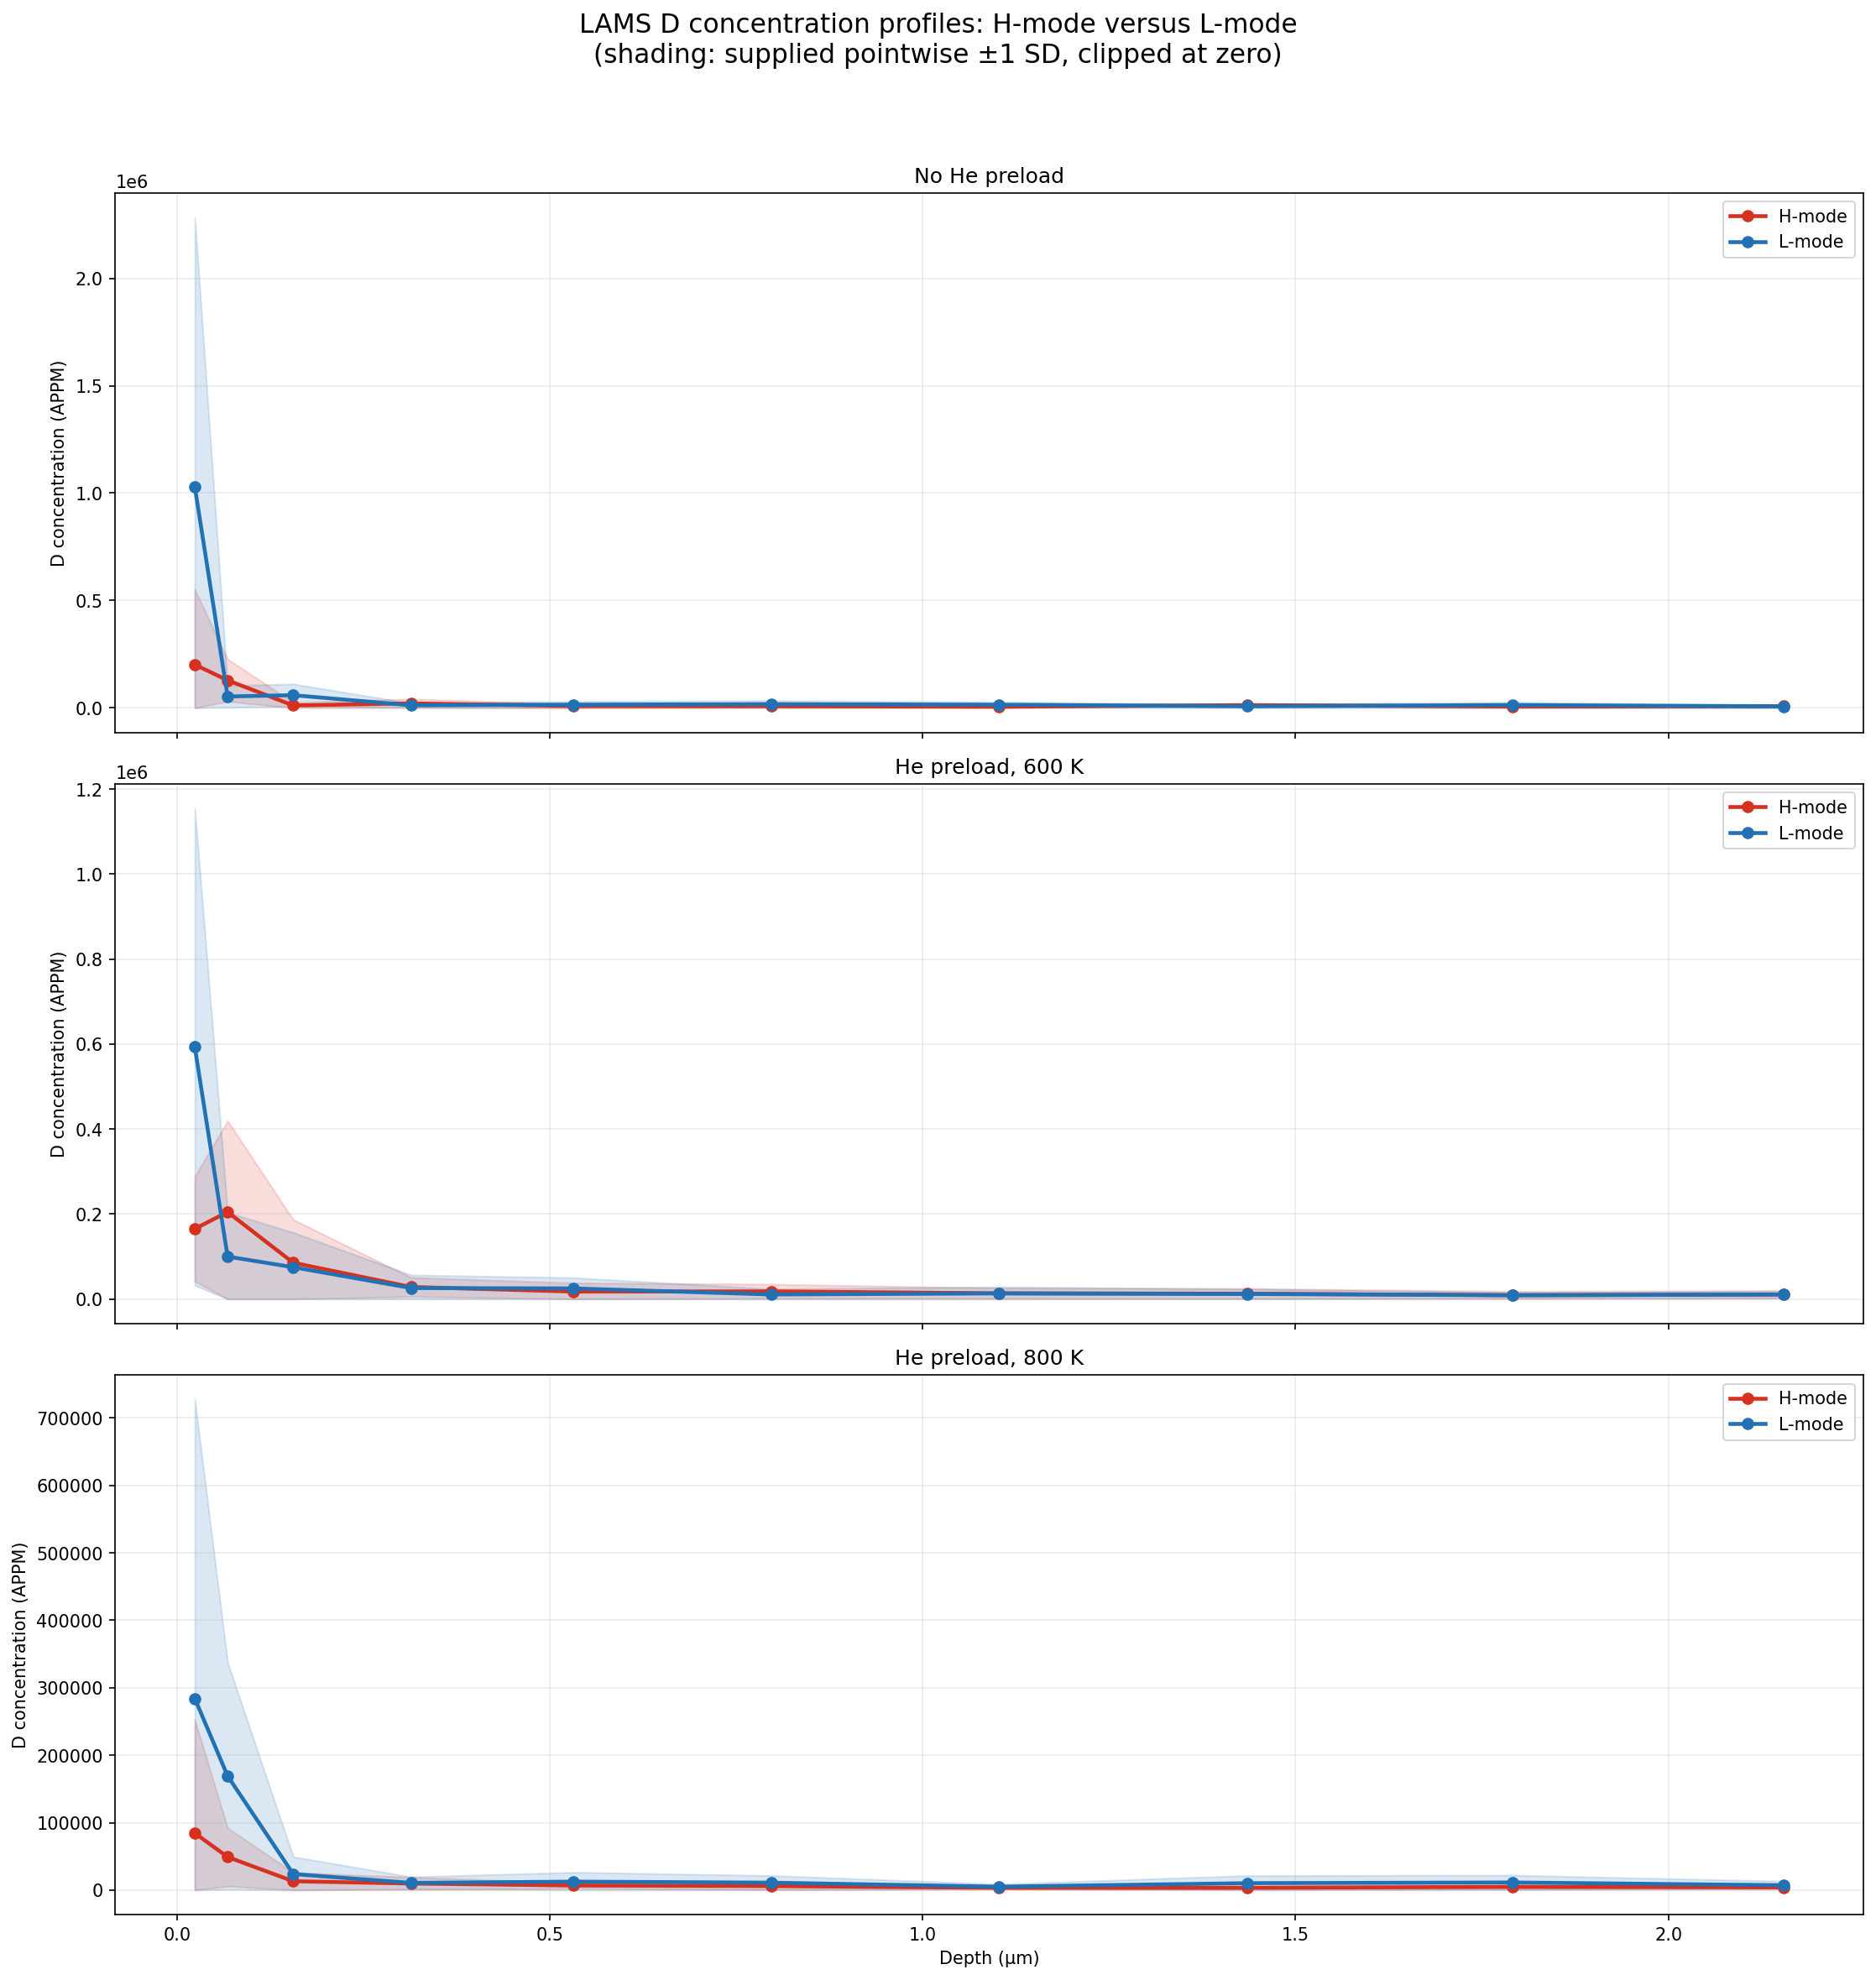

The depth-resolved pattern differs substantially by helium condition:

- **No helium** : L-mode is higher at 6 of 10 depths and lower at 4. The profile is not a uniform upward shift, even though its integrated central value is 75% higher.
- **600 K preload** : L-mode is lower at 7 of 10 depths and higher at 3. Large near-surface increases compensate for deeper decreases, leaving the integrated profile almost exactly unchanged.
- **800 K preload** : the L-mode central value is higher at **all 10 depths** , ranging from a 9% increase at 0.314 µm to a 245% increase at 0.068 µm. This is the only helium class for which LAMS gives a uniform directional result across the complete reported profile.

Percentage changes at individual depths can become very large when the H-mode denominator is relatively small. The absolute APPM values and their standard deviations are therefore retained in the associated CSV rather than interpreting the percentages alone.

## Measurement uncertainty

### ERDA

ERDA is the only method here with supplied uncertainties on a directly reported coupon-level scalar.

Propagating the H- and L-mode standard deviations as independent errors gives:

| Helium preload | L−H difference relative to propagated SD | Interpretation of supplied measurement error |
|---|---:|---|
| None | 3.26 SD | L-mode central value exceeds H-mode |
| 600 K | 8.49 SD | L-mode central value exceeds H-mode |
| 800 K | 13.93 SD | L-mode central value exceeds H-mode |

These ratios address only the supplied ERDA measurement uncertainty. They are **not treatment-effect significance tests** , because each experimental cell contains one coupon. They omit coupon-to-coupon variation and campaign reproducibility.

### NRA

No numerical NRA uncertainty was supplied for either depth band. Therefore:

- The absolute and percentage changes are calculable.
- Error bars cannot be propagated.
- The apparent size or statistical significance of the NRA differences cannot be evaluated from this delivery.
- Missing uncertainty must not be interpreted as zero uncertainty.

### LAMS

The LAMS profile rows include a standard deviation at every depth, but these values are often comparable to or larger than the measured concentration. I propagated them into the profile-area summary using trapezoidal weights:

$$
\sigma_A=\sqrt{\sum_i (w_i\sigma_i)^2},
$$

assuming independent errors among depths. The resulting L−H profile-area differences are:

| Helium preload | Integrated L−H difference relative to propagated SD |
|---|---:|
| None | 0.77 SD |
| 600 K | 0.0001 SD |
| 800 K | 1.26 SD |

On this error model, none of the LAMS integrated differences is strongly resolved. Even the 800 K result—where every central profile point is higher under L-mode—has a profile-area difference of only about 1.26 propagated standard deviations.

The integration uncertainty includes the supplied concentration standard deviations but not uncertainty in depth coordinates, calibration, or systematic errors. It also assumes independent depth points. Correlation among profile points could materially change the resulting uncertainty.

### Experimental replication

The most important common limitation is that every L/H × helium-preload design cell contains **one coupon** . Consequently:

- Instrument repeatability is not the same as uncertainty in the L/H treatment contrast.
- Coupon-to-coupon variability cannot be estimated.
- The very small ERDA measurement errors do not establish that the same percentage change would occur in a replicated set of tungsten coupons.
- The L/H differences are descriptive comparisons of these six exposed coupons, not population-level estimates.

## Overall conclusion

The answer depends materially on the retention technique:

1. **ERDA** indicates that L-mode exposure increased the method-reported areal D concentration in all three helium classes, by **27%, 63%, and 199%** for no-helium, 600 K, and 800 K preloads.

2. **NRA** also indicates an increase in every case. Its summed 0–3 µm inventories rise by **27%, 100%, and 354%** , and both NRA depth bands increase in all three helium classes.

3. **LAMS** gives a more heterogeneous result. Its integrated central estimate rises **75%** without helium, changes by essentially **0%** for the 600 K preload, and rises **136%** for the 800 K preload. Only the 800 K profile is higher at every reported depth.

4. **The 800 K helium-preloaded coupons show the strongest cross-technique agreement** : ERDA, both NRA bands, and all ten LAMS profile points are higher following the L-mode campaign.

5. **The 600 K coupons show the strongest technique dependence** : ERDA and NRA indicate substantially more D following L-mode, while LAMS finds almost no change in its profile-area index and mixed changes with depth.

6. The difference should not be attributed to confinement mode alone. The L-mode campaign simultaneously had higher particle fluence, particle flux, impact energy, density, and electron temperature, along with lower heat flux and shorter duration.

## Data files

All supporting files are in `/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_`.

- `lh_total_retention_changes_by_technique.csv` — H/L values, absolute differences, ratios, percentage changes, and available propagated uncertainties for ERDA, summed NRA, and integrated LAMS.
- `lh_nra_depth_band_changes.csv` — NRA surface and sub-surface inventories and L/H changes.
- `lh_lams_depth_profile_changes.csv` — all 30 paired depth comparisons with APPM values, supplied standard deviations, ratios, and propagated uncertainties.
- `lh_diiid_exposure_condition_changes.csv` — recorded H- and L-campaign conditions and their differences.
- `lh_retention_analysis_summary.json` — machine-readable analysis summary, including all method-level results and LAMS depth-direction patterns.
- `lh_retention_authoritative_query.json` — authoritative materials-lakehouse response containing samples, experimental design, exposure conditions, method discovery, measurements, profiles, provider notes, and the scoped literature retrieval.

In [6]:
%%ask
Quantify changes in D retention with changes in DIII-D plasma conditions 
(L vs. H mode). Include both changes in the total D retention measured 
as well as D retention as a function of depth. As done previously, comment 
on differences in the answer based on the retention measurement technique 
that was used. 

## 4 — What this does not establish

A closing question about the limits of the dataset rather than its contents.


In [7]:
%%ask
Given these tungsten samples and the retention measurements delivered with
them, what do the results collectively support, what would they not be
sufficient to claim, and what further measurement would be needed?

I’ll synthesize the delivered measurements, distinguish supported findings from overclaims, and identify the experiment needed to resolve the main uncertainty.

I’m reading the materials skill to use the delivery’s authoritative query interface and interpret its measurement semantics correctly.

The skill has an existing learning record, so I’m checking it before querying to avoid known mistakes and apply established fixes.

The skill confirms that all methods, design replication, provider notes, and attached literature must be evaluated together; I’m advancing to the authoritative query.

Because the question asks what further measurement is needed, I’m consulting the literature skill before writing the combined query script.

...

The synthesis produced 28 traceable comparisons; I’m reading the CSV and assessment text to verify values and wording before reporting.

The evidence table confirms the earlier cross-method values; I’m checking the final assessment’s supported and unsupported claim boundaries.

The synthesis is complete: it supports condition- and depth-dependent behavior, but not population-level causality, a universal helium effect, or a unique mechanism.

I audited the tool history: both scripts ran successfully on their first execution, so no edit-and-retry learning entry is required; no image was read.

**Bottom line** : Collectively, these measurements support the conclusion that deuterium retention in the delivered tungsten coupons depends on both exposure history and depth, and that helium can substantially modify—but does not universally reduce—the retained-D distribution. They are not sufficient to establish a population-level causal effect, a confinement-mode-only effect, or a unique helium-nanobubble mechanism; the highest-priority additional measurement is calibrated thermal-desorption spectroscopy on matched, replicated coupons, while retaining an independent depth-profile measurement.

## What the measurements collectively support

### 1. Helium preloading can produce a large change in measured D retention

The clearest internally consistent result is the **800 K helium-preloaded coupon exposed in H-mode** . Relative to the no-helium H-mode coupon:

| Measurement | Helium-associated change |
|---|---:|
| ERDA method-reported areal D | −42% ± 5 percentage points |
| NRA, 0–0.5 µm | −68%; uncertainty not supplied |
| NRA, 0.5–3 µm | −77%; uncertainty not supplied |
| LAMS profile area, 0.024–2.155 µm | −50% ± 25 percentage points |

All three techniques therefore give a lower central measurement for this particular comparison. That supports a **helium-associated reduction extending across the measured near-surface and sub-surface regions** for the 800 K/H-mode condition.

It is important that this conclusion is framed as a comparison between these two coupons. The error bars do not include coupon-to-coupon variation because each condition has only one sample.

### 2. The helium effect is conditional, not universal

The 600 K/H-mode comparison points in the opposite direction:

- ERDA: **+27%** .
- NRA at 0–0.5 µm: **+14%** .
- NRA at 0.5–3 µm: **+33%** .
- LAMS profile-area central estimate: **+68%** , but with an uncertainty of approximately 89 percentage points.

In L-mode, helium increases the ERDA and NRA surface measurements while decreasing the NRA sub-surface measurement:

| Helium preload | ERDA | NRA, 0–0.5 µm | NRA, 0.5–3 µm | LAMS profile area |
|---|---:|---:|---:|---:|
| 600 K | +63% | +121% | −24% | −4% |
| 800 K | +36% | +35% | −59% | −33% |

These results support **redistribution with depth** as well as changes in overall measured retention. They do not support a statement that helium simply suppresses D retention under every condition.

### 3. The DIII-D campaign conditions also matter

Relative to the H-mode coupon with the same helium-preload history, the L-mode coupon has:

- **27%, 63%, and 199% more D by ERDA** for no-helium, 600 K, and 800 K preloads, respectively.
- Higher NRA inventories in both the 0–0.5 and 0.5–3 µm bands for all three preload classes.
- Mixed LAMS results: **+75%** without helium, essentially **0%** after the 600 K preload, and **+136%** after the 800 K preload.

Thus, the measurements support a strong dependence on the **combined plasma campaign and helium-preload history** . The 800 K coupons show the strongest cross-technique L-over-H difference, while the 600 K coupons show the strongest disagreement between the areal techniques and the integrated LAMS profile.

### 4. Measurement-technique disagreement is itself a result

The methods should not be averaged into a single number:

- **ERDA** reports one method-specific areal concentration per coupon.
- **NRA** separates D into 0–0.5 and 0.5–3 µm bands, exposing changes in depth distribution.
- **LAMS** reports an APPM depth profile. Its integrated profile area is a within-LAMS comparison in APPM µm, not a calibrated areal inventory interchangeable with ERDA or NRA.

The agreement for 800 K/H-mode strengthens the qualitative inference for that comparison. The disagreement in other comparisons indicates that helium and plasma history may change **where D resides** , not merely multiply the concentration uniformly at all depths.

## What these results are not sufficient to claim

### 1. They do not establish a population-level causal treatment effect

There are **nine experimental-design cells and one coupon in every cell** . Consequently, a difference between two cells could contain:

- A true exposure effect.
- Coupon-to-coupon variability.
- Variation in sample preparation or microstructure.
- Unmeasured spatial variability.
- Campaign-to-campaign variability.

The supplied analytical uncertainties describe aspects of each measurement. They do not estimate how repeat tungsten coupons would respond to the same treatment.

### 2. They do not show that helium always reduces D retention

The 800 K/H-mode comparison shows a consistent reduction, but several other helium comparisons show increases in ERDA or surface NRA. A defensible statement is that helium **modifies retention in a condition- and depth-dependent manner** , not that helium is universally protective against fuel retention.

### 3. They do not isolate the effect of helium-preload temperature

The labels “600 K” and “800 K” refer to different PISCES-A helium treatments, but those treatments also differed in helium flux, exposure duration, and slightly in fluence. The observed contrast cannot be attributed uniquely to temperature.

### 4. They do not isolate confinement mode

The H-mode and L-mode campaigns differed simultaneously in:

- Particle fluence and flux.
- Heat flux.
- Exposure duration.
- Impact energy.
- Electron density.
- Electron temperature.

In addition, neither bulk nor surface coupon temperature during the DIII-D exposure was measured. Therefore, “L-mode caused more retention than H-mode” would be too strong. The data support a difference between the **recorded L-mode and H-mode campaigns as conducted** , not a pure confinement-mode effect.

### 5. They do not provide a technique-independent whole-coupon D inventory

None of the delivered results alone guarantees a complete bulk inventory:

- NRA covers the reported 0–3 µm region.
- LAMS covers 0.024–2.155 µm and is reported as APPM rather than a directly comparable areal total.
- The delivered ERDA scalar is method-specific and does not resolve the depth distribution.
- D residing deeper than the effective measurement range could be missed or represented differently among methods.

The summed NRA bands, ERDA scalar, and integrated LAMS profile should therefore not be treated as three estimates of one identical “total D” quantity.

### 6. They do not uniquely establish a helium-nanobubble permeation barrier

The pattern is compatible with helium altering inward D transport, especially for the 800 K/H-mode coupon, but compatibility is not proof of mechanism. These samples do not by themselves demonstrate:

- That a nanobubble layer of a specified thickness or porosity formed.
- That this layer caused the retention difference.
- Whether the change arose from reduced implantation, modified diffusion, altered trapping, increased recycling, or some combination.

Baldwin and Doerner’s separate PISCES-A study used TDS and transport modeling to infer a helium-affected permeation barrier. That study provides relevant context, but it is not a direct measurement of the mechanism in the present DIII-D coupons.

## How uncertainty limits the conclusion

### ERDA

ERDA supplied standard deviations for the exposed coupons:

- **Relative standard-deviation range** : approximately 3.8–7.2%.
- The propagated uncertainties on many ERDA coupon-to-coupon percentage differences are small compared with the differences.

This means that the ERDA instrument-level contrasts are well resolved under the supplied error model. It does **not** mean that the exposure treatment is statistically established, because the error model lacks biological-style—or, here, coupon-to-coupon—replication.

### NRA

There are 12 NRA D results across the six DIII-D-exposed coupons and two depth bands, but **none has a supplied numerical uncertainty** . The analyst reported that sub-surface D was above an approximately 10 APPM detection limit, which supports detection, but does not quantify uncertainty in the reported areal inventories or their differences.

Accordingly, NRA supplies valuable depth-direction evidence, but not enough information to calculate confidence intervals or significance for those contrasts.

### LAMS

All 60 LAMS profile points for the six exposed coupons carry standard deviations, but the pointwise values are large:

- **Relative pointwise standard-deviation range** : approximately 47–199%.
- Derived profile-area contrasts consequently have broad uncertainties.
- The uncertainty propagation assumes independent depth points, which has not been demonstrated.

LAMS is therefore most informative here about the possible **shape and direction of depth-dependent changes** , while the magnitudes of many individual or integrated differences remain weakly constrained.

## The highest-priority further measurement

### Calibrated thermal-desorption spectroscopy

The most useful additional diagnostic would be **calibrated thermal-desorption spectroscopy or thermal-desorption mass spectrometry (TDS)** carried through a temperature ramp sufficient to release and quantify the retained D inventory.

TDS would add two quantities that the delivered measurements do not provide directly:

1. **Integrated releasable bulk inventory** : the time- or temperature-integrated D$_2$, HD, and relevant hydrogen-isotope signals can quantify how much retained D leaves the coupon during heating.
2. **Desorption spectrum** : peak temperatures and shapes constrain release kinetics and trapping states, helping distinguish a change in inventory from a change in transport or trap binding.

Baldwin and Doerner used this type of measurement to compare bulk D desorption from control and helium-affected tungsten and explicitly combined the desorption behavior with NRA depth information. Their study also notes that an accurately measured pre-TDS depth profile can be supplied to transport modeling instead of inferring the initial inventory profile.

### TDS should be paired with depth profiling

TDS is destructive and collapses the depth distribution into a release spectrum. It should therefore be paired with:

- NRA or LAMS on a matched companion coupon; or
- A depth profile acquired before TDS, where technically feasible.

This combination would distinguish:

- Less D retained overall.
- The same inventory redistributed in depth.
- A similar inventory released at different temperatures because trapping changed.

A post-TDS residual-D check would also test whether the thermal ramp achieved effectively complete release.

## What the follow-up experiment needs beyond TDS

TDS on one of the existing coupons could clarify its inventory, but it would not solve the causal-inference problem. A decisive follow-up should include:

1. **Multiple coupons per cell** to estimate coupon-to-coupon variability.
2. **Independent repetitions of the exposure campaigns** , not only repeated instrumental measurements on one coupon.
3. **Matched coupons for TDS and depth profiling** , because TDS is destructive.
4. **Measured coupon surface and bulk temperature during DIII-D exposure** .
5. **A confinement-mode comparison with other plasma parameters held as nearly fixed as possible** .
6. **Separated helium-treatment variables** , rather than changing temperature, flux, duration, and fluence together.
7. **Direct cross-sectional TEM or equivalent nanobubble characterization** if the intended claim is specifically that a helium-nanobubble barrier caused the retention change.

## Overall evidentiary statement

The strongest conclusion justified by the delivered data is:

> The tungsten coupons show reproducible-across-method directionality for some individual comparisons—most notably reduced measured D after the 800 K helium preload under the H-mode campaign—but the full dataset shows that the helium-associated effect depends on plasma campaign, probing depth, and measurement technique.

The results are best treated as **evidence motivating a replicated, multimethod experiment** , not as a definitive quantitative law for helium suppression of D retention in tungsten.

## Data files

All supporting text data are in `/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_`.

- `collective_support_evidence.csv` — 28 recomputed helium/no-helium and L/H comparisons, including method, depth basis, values, percentage changes, and available propagated uncertainties.
- `collective_support_assessment.json` — structured supported claims, unsupported claims, uncertainty coverage, and follow-up measurement requirements.
- `collective_support_authoritative_query.json` — authoritative samples, experimental design, observations, depth profiles, exposure conditions, provider notes, document-search results, and scoped literature passages.

## References

M.J. Baldwin and R.P. Doerner (2017) Hydrogen isotope transport across tungsten surfaces exposed to a fusion relevant He ion fluence. Nuclear Fusion 57 076031 doi:10.1088/1741-4326/aa70b1